<a href="https://colab.research.google.com/github/riteshyadav-345/MachineLearning/blob/main/Day19_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### K-Nearest Neighbors (KNN) Implementation

This example demonstrates a complete workflow for implementing the K-Nearest Neighbors (KNN) algorithm, from generating synthetic data to evaluating the model's performance.

In [1]:
# 1. Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

#### 2. Generate Synthetic Data

We'll create a synthetic dataset for a binary classification problem using `make_classification`.

In [2]:
# Generate synthetic dataset
X, y = make_classification(n_samples=200, n_features=10, n_informative=5,
                           n_redundant=2, n_classes=2, random_state=42)

df = pd.DataFrame(X, columns=[f'feature_{i+1}' for i in range(X.shape[1])])
df['target'] = y

print("First 5 rows of the dataset:")
display(df.head())
print("\nTarget distribution:")
display(df['target'].value_counts())

First 5 rows of the dataset:


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,target
0,-0.346347,0.615105,-1.599136,-0.025077,-1.835385,-0.071393,-0.079900,-0.088343,2.149471,-0.406723,1
1,1.353891,-2.552883,0.569950,-0.838090,-1.517482,0.915475,0.464008,0.635397,-0.537256,0.721466,0
2,0.136336,2.473938,2.155743,-0.054096,-1.777367,-1.255051,-1.211360,0.836324,5.026974,-1.131453,1
3,-1.471314,-1.610811,1.811375,-1.426168,-0.222879,-1.767294,1.903552,0.328652,-1.092684,0.623549,0
4,0.767585,0.107784,-0.353016,-1.634055,-3.142936,-1.774286,-0.370667,1.313069,4.881878,-1.036576,1



Target distribution:


,count
target,
0,101
1,99


#### 3. Split Data into Training and Testing Sets

We split the dataset into training and testing sets to evaluate the model's generalization performance.

In [3]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 140 samples
Test set size: 60 samples


#### 4. Data Preprocessing: Feature Scaling

KNN is sensitive to the scale of the features because it relies on distance metrics. We'll use `StandardScaler` to normalize the features.

In [4]:
# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully.")

Features scaled successfully.


#### 5. Train the K-Nearest Neighbors Model

We'll initialize `KNeighborsClassifier` and train it on the scaled training data. A common practice is to choose an odd number for `n_neighbors` to avoid ties in binary classification.

In [5]:
# Initialize KNN classifier (e.g., with k=5)
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn.fit(X_train_scaled, y_train)

print(f"KNN model trained with n_neighbors={knn.n_neighbors}.")

KNN model trained with n_neighbors=5.


#### 6. Make Predictions

Use the trained model to make predictions on the scaled test data.

In [6]:
# Make predictions on the scaled test set
y_pred = knn.predict(X_test_scaled)

print("Predictions made on the test set.")

Predictions made on the test set.


#### 7. Evaluate the Model

We'll evaluate the model's performance using common classification metrics: accuracy, precision, recall, F1-score, and a confusion matrix.

Accuracy: 0.8833
Precision: 0.8710
Recall: 0.9000
F1-Score: 0.8852

Confusion Matrix:
[[26  4]
 [ 3 27]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.87      0.88        30
           1       0.87      0.90      0.89        30

    accuracy                           0.88        60
   macro avg       0.88      0.88      0.88        60
weighted avg       0.88      0.88      0.88        60



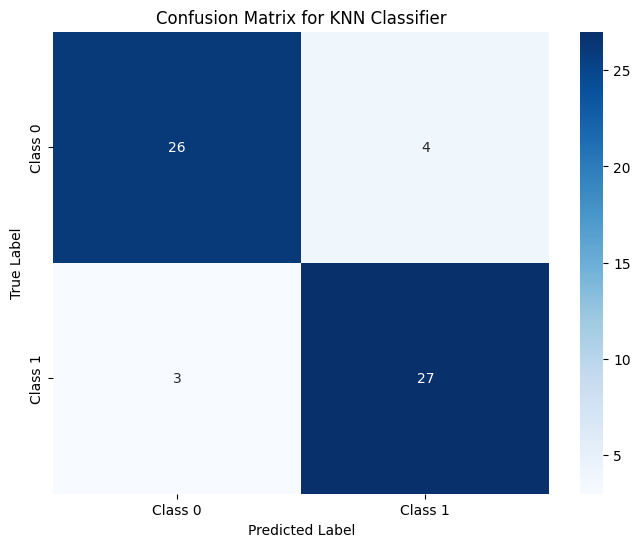

In [7]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix)

print("\nClassification Report:")
print(class_report)

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for KNN Classifier')
plt.show()

#### 8. Hyperparameter Tuning (Optional: Finding Optimal `k`)

This section demonstrates how to find a better `n_neighbors` (k) value by iterating through different values and evaluating their accuracy. This is a simple form of hyperparameter tuning.

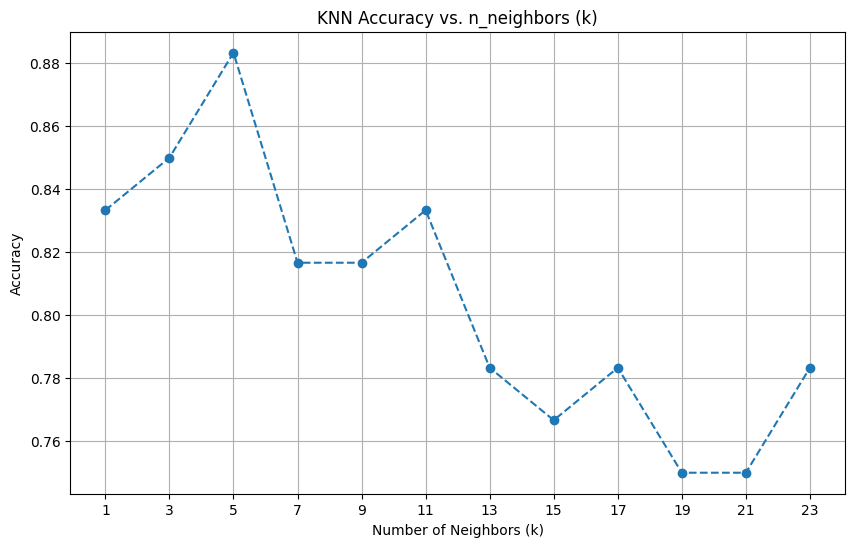

Optimal 'k' value found: 5 with accuracy: 0.8833


In [8]:
accuracies = []
max_k = min(X_train_scaled.shape[0] // 2, 25) # Limit k to avoid overfitting and computational cost

for i in range(1, max_k, 2): # Iterate over odd k values
    knn_i = KNeighborsClassifier(n_neighbors=i)
    knn_i.fit(X_train_scaled, y_train)
    y_pred_i = knn_i.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, y_pred_i))

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(range(1, max_k, 2), accuracies, marker='o', linestyle='--')
plt.title('KNN Accuracy vs. n_neighbors (k)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.xticks(range(1, max_k, 2))
plt.grid(True)
plt.show()

best_k_index = np.argmax(accuracies)
best_k = range(1, max_k, 2)[best_k_index]
best_accuracy = accuracies[best_k_index]

print(f"Optimal 'k' value found: {best_k} with accuracy: {best_accuracy:.4f}")